In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pickle
from PIL import Image
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter

In [2]:
EPS = 1e-8

In [3]:
def normalize_stack(stack):

    stack = stack.astype(np.float32)
    if stack.max() > 1.5:
        stack = stack / stack.max()
    else:
        stack = np.clip(stack, 0, 1)

    return stack
    
def normalize_all_videos(trainingSet):
        normed = {}
        for t, stack in trainingSet.items():
            normed[t] = normalize_stack(stack)
            
        return normed


class SEMDataset:

    def __init__(self,
                 folder_path):

        self.folder_path = folder_path
        stacks_raw = self.load_all_tiffs()

        self.stacks = normalize_all_videos(stacks_raw)

    # ========================================================
    # load multi-frame TIFF stacks
    # ========================================================

    def load_all_tiffs(self):

        stacks = {}

        for filename in os.listdir(
            self.folder_path
        ):

            if not filename.lower().endswith(
                (".tif", ".tiff")
            ):
                continue

            path = os.path.join(
                self.folder_path,
                filename
            )

            dwell = int(
                os.path.splitext(filename)[0]
            )

            with Image.open(path) as img:

                frames = []

                for i in range(img.n_frames):

                    img.seek(i)

                    frames.append(
                        np.array(img)
                    )

            stacks[dwell] = np.stack(frames)

        return stacks
    

    # ========================================================
    # visualize one frame from each dwell
    # ========================================================

    def visualize_frames(self,
                         frame_idx=0,
                         cmap='gray'):

        ts = sorted(
            self.stacks.keys()
        )

        for t in ts:

            frame = self.stacks[t][frame_idx]

            plt.figure(figsize=(6,6))

            im = plt.imshow(
                frame,
                cmap=cmap
            )

            plt.title(
                f"Dwell Time = {t}"
            )

            plt.axis('off')

            plt.colorbar(
                im,
                fraction=0.046
            )

            plt.show()


In [4]:
def estimate_signal(stack):
    
    return np.mean(stack,axis=0).astype(np.float32)


def estimate_corr_length(img):

    img = img.astype(np.float32)

    f = np.fft.fft2(img)

    psd = np.abs(f)**2

    fy = np.fft.fftfreq(img.shape[0])
    fx = np.fft.fftfreq(img.shape[1])

    FX, FY = np.meshgrid(fx, fy)

    r2 = FX**2 + FY**2

    psd = psd + EPS

    psd /= np.sum(psd)

    spectral_width = np.sum(r2 * psd)

    corr_len = 1.0 / np.sqrt(
        spectral_width + EPS
    )

    return corr_len

# ========================================================
# empirical SEM statistics
# ========================================================

def compute_stats(allTiffs):

    stats = {}

    for t, stack in allTiffs.items():

        signal = estimate_signal(stack)
        residuals = (stack.astype(np.float32) - signal[None])

        sigmas = []
        corrs = []

        for frame in residuals:
            sigmas.append(np.std(frame))
            corrs.append(estimate_corr_length(frame))

        stats[t] = {"signal":signal,
                    "noise":residuals[0],
                    "sigma":np.mean(sigmas),
                    "corr":np.mean(corrs)}

    return stats


def gaussian_field(shape,corr):

    z = np.random.randn(*shape)

    fy = np.fft.fftfreq(shape[0])
    fx = np.fft.fftfreq(shape[1])

    FX, FY = np.meshgrid(fx, fy)

    f2 = FX**2 + FY**2

    lam = 1.0 / (corr + EPS)

    filt = 1.0 / (1.0 + f2 / (lam**2 + EPS))

    zf = np.fft.fft2(z)

    z = np.real(np.fft.ifft2(zf * filt))

    # ----------------------------------------------------
    # SEM grain enhancement
    # ----------------------------------------------------

    factor = max(int(corr / 2),1)

    small = cv2.resize(z,( shape[1] // factor, shape[0] // factor),interpolation=cv2.INTER_AREA)

    z = cv2.resize(small,(shape[1],shape[0]),interpolation=cv2.INTER_NEAREST)

    z -= np.mean(z)   
    z /= (np.std(z) + EPS)

    return z

In [5]:
class SEMNoiseModel:

    def __init__(self):

        self.model = None

    def sigma_tail_model(self,t,a,alpha):
        return a * (t ** (-alpha))
    
    def corr_tail_model(self,t,d,beta):
        return d * (t ** (-beta))


    def fit(self,stats):

        ts = np.array(sorted(stats.keys()),dtype=np.float32)
        u = np.log(ts + EPS)
        
        sigma = np.array([stats[t]["sigma"] for t in ts])
        corr = np.array([stats[t]["corr"] for t in ts])
        
        sigma_spline = CubicSpline(u,sigma)

        corr_spline = CubicSpline(u,corr)

        # sigma extrapolation
        p0_sigma = [sigma[0],0.5,]
        sigma_tail_params, _ = curve_fit(self.sigma_tail_model, ts, sigma, p0=p0_sigma, maxfev=40000 )

        # corr extrapolation
        p0_corr = [corr[0],0.5]
        corr_tail_params, _ = curve_fit( self.corr_tail_model, ts, corr, p0=p0_corr, maxfev=40000)

        self.model = {

            "sigma_spline":
                sigma_spline,

            "corr_spline":
                corr_spline,

            "sigma_tail":
                sigma_tail_params,

            "corr_tail":
                corr_tail_params,
        }

    
    def save_model(self,savePath):
        with open(savePath, "wb") as f:
            pickle.dump(self.model, f)

    
    def load_model(self, loadPath):
        with open(loadPath, "rb") as f:
            self.model = pickle.load(f)

    
    def eval_model_at_t(self,t):

        model = self.model
        u = np.log(t + EPS)

        sigma_spline = model["sigma_spline"]
        corr_spline = model["corr_spline"]

        u_min = sigma_spline.x[0]
        u_max = sigma_spline.x[-1]


        a, alpha = model["sigma_tail"]

        if u_min <= u <= u_max:
            sigma = float(sigma_spline(u))
            corr = float(corr_spline(u))

        elif u > u_max:
            a, alpha = model["sigma_tail"]
            sigma = self.sigma_tail_model(t,a,alpha)
            d, beta = model["corr_tail"]
            corr = self.corr_tail_model(t,d,beta)
        
        else:
            sigma = float(sigma_spline(u_min))
            corr = float(corr_spline(u_min))
        

        sigma = max(sigma, 0)
        corr = max(corr, 0.5)

        return sigma, corr


    def generate(self, image_high, t_high, t_target):

        dtype = image_high.dtype

        image_high = image_high.astype(np.float32)

        # global normalization
        if np.issubdtype(dtype,np.integer):

            input_max = np.iinfo(dtype).max
            signal = image_high / input_max

        else:
            input_max = 1.0
            signal = np.clip(image_high,0,1)

        sigma_h, corr_h = self.eval_model_at_t(t_high)
        sigma_t, corr_t = self.eval_model_at_t(t_target)

        delta_sigma2 = (sigma_t**2 - sigma_h**2)

        delta_sigma2 = np.maximum(delta_sigma2,0)

        delta_sigma = np.sqrt(delta_sigma2)

        
        g = gaussian_field(signal.shape,corr_t)

        
        output = (signal + delta_sigma * g)

        output = np.clip(output,0,1)

        
        if np.issubdtype(dtype,np.integer):
            output = (output * input_max).astype(dtype)
        else:
            output = output.astype(np.float32)

        return output

    # ========================================================
    # evaluate generator
    # ========================================================

    def evaluate_generator(self,allTiffs):

        stats = compute_stats(allTiffs)

        ts = np.array(sorted(stats.keys()))

        t_high = ts[-1]

        base = estimate_signal(allTiffs[t_high])

        sigma_emp = []
        sigma_gen = []

        corr_emp = []
        corr_gen = []

        for t in ts:

            sigma_emp.append(stats[t]["sigma"])

            corr_emp.append(stats[t]["corr"])

            generated = self.generate(base,t_high,t)

            residual = (generated.astype(np.float32) - base.astype(np.float32))

            sigma_gen.append(np.std(residual))

            corr_gen.append(estimate_corr_length(residual))

        fig, axs = plt.subplots(1,2,figsize=(12,5))

        # sigma
        axs[0].plot(ts,sigma_emp,'o-',label='empirical')
        axs[0].plot(ts,sigma_gen,'s--',label='generated')
        axs[0].set_xscale('log')

        axs[0].set_title("Generated Sigma")
        axs[0].grid(True)
        axs[0].legend()

        # corr
        axs[1].plot(ts,corr_emp,'o-',label='empirical')
        axs[1].plot(ts,corr_gen,'s--',label='generated')
        axs[1].set_xscale('log')
        axs[1].set_title("Generated Correlation")
        axs[1].grid(True)
        axs[1].legend()
        
        plt.tight_layout()
        plt.show()

    # ========================================================
    # visualize generated noise
    # ========================================================

    def visualize_generated_noise(self,testImage,t_high,dwell_list):

        base = testImage.astype(np.float32)

        for t in dwell_list:

            generated = self.generate(testImage,t_high,t)
            noise = (generated.astype(np.float32) - base)

            vmax = np.percentile(np.abs(noise),99)

            fig, axs = plt.subplots(1,2,figsize=(12,5))

            im0 = axs[0].imshow(generated,cmap='gray')

            axs[0].set_title(f"Generated SEM\n{t_high} → {t}")

            axs[0].axis('off')

            plt.colorbar(im0,ax=axs[0],fraction=0.046)

            # noise
            im1 = axs[1].imshow(noise,cmap='gray',vmin=-vmax,vmax=vmax)

            axs[1].set_title(f"Generated Noise\nDwell={t}")

            axs[1].axis('off')

            plt.colorbar(im1,ax=axs[1],fraction=0.046)
            plt.tight_layout()
            plt.show()

In [6]:
def load_tiff_stack(path):
    img = Image.open(path)

    frames = []
    try:
        for i in range(img.n_frames):
            img.seek(i)
            frames.append(np.array(img))
    except AttributeError:
        # single image fallback
        frames = [np.array(img)]

    return np.stack(frames)

In [7]:
data = SEMDataset('../Noise_evaluation_dataset_1')

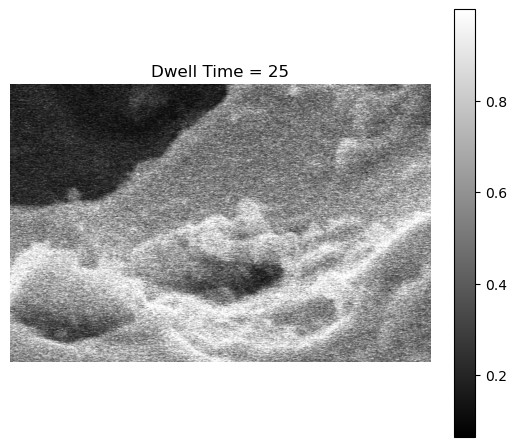

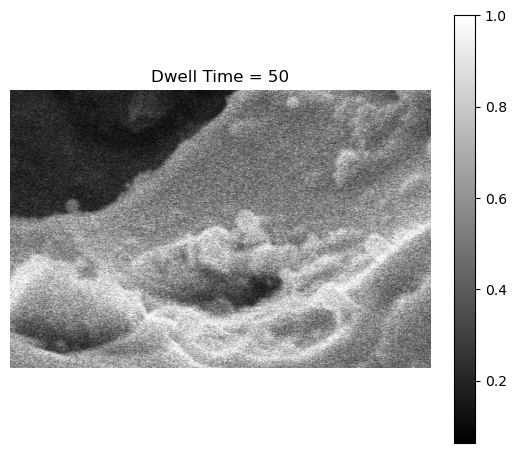

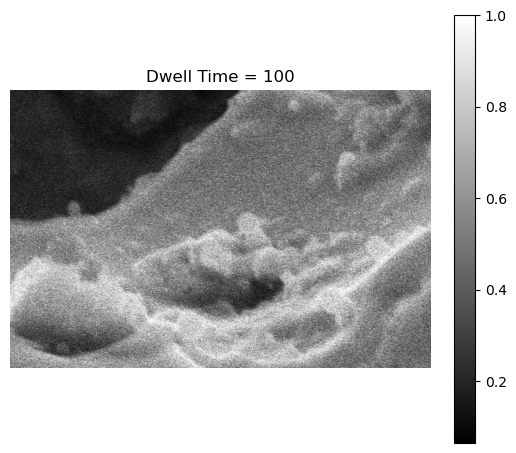

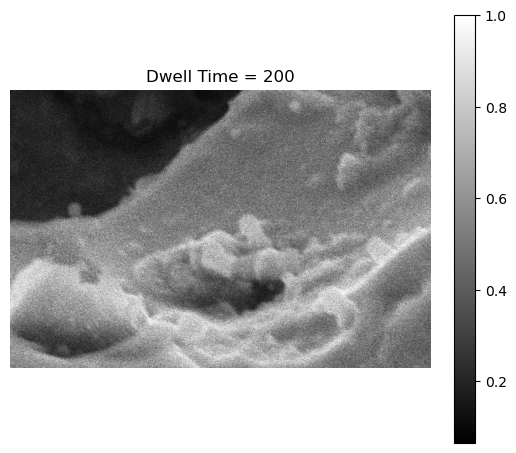

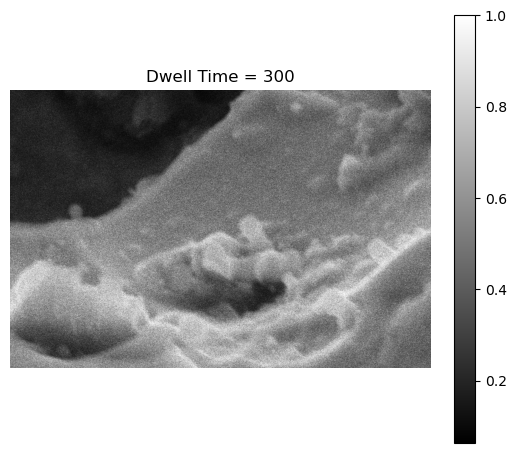

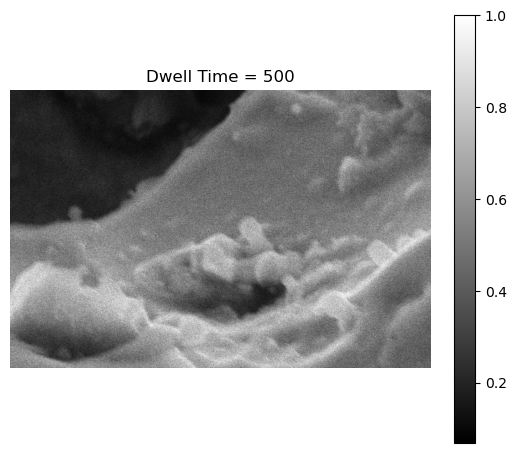

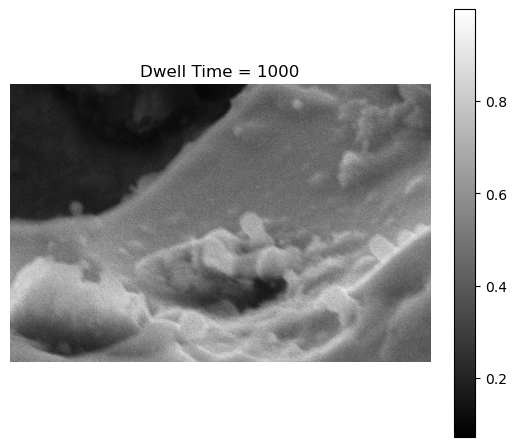

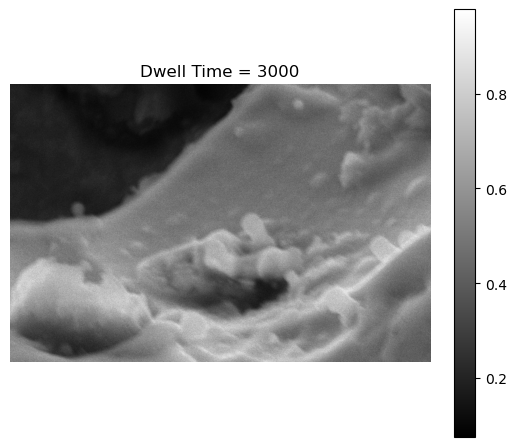

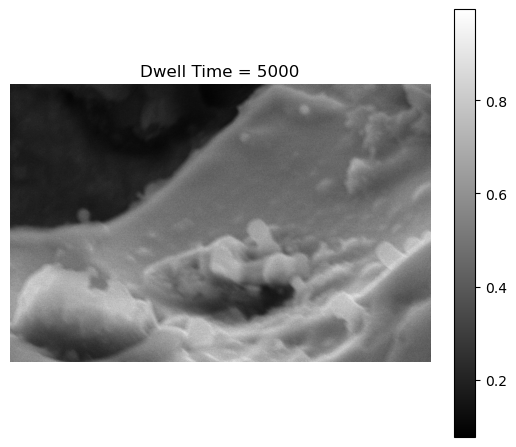

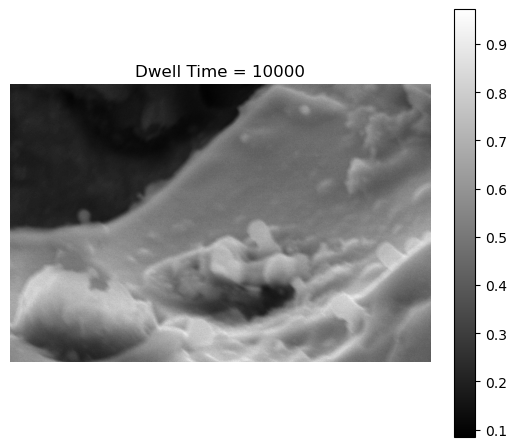

In [8]:
data.visualize_frames(frame_idx=5)

In [ ]:
stats = compute_stats(data.stacks)

In [ ]:
sem_model = SEMNoiseModel()

In [ ]:
sem_model.fit(stats)
sem_model.save_model('sem_noise_model.pkl')

Load from pre-trained model

In [ ]:
sem_model_two = SEMNoiseModel()

In [ ]:
sem_model_two.load_model('sem_noise_model.pkl')

In [ ]:
testImage = load_tiff_stack('../Li_Expulsion_1.tif')[5]

In [ ]:
plt.imshow(testImage,cmap='grey')
plt.colorbar()
plt.show()

In [ ]:
ts = list(np.append(sorted(data.stacks.keys()),[20000,40000]))

In [ ]:
for t in ts:
    generated = sem_model_two.generate(testImage,t_high=20000,t_target=t)
    plt.imshow(generated,cmap='grey')
    plt.colorbar()
    plt.show()